# 09 - Bayesian Nonparametric Mixtures

**Problem framing.** Everywhere else in this lab we *choose* the number of clusters and then defend the choice. A Dirichlet-process Gaussian mixture inverts that: we give it a generous upper bound on components and the variational prior shrinks the weight of the components it does not need toward zero, so the *effective* number of clusters is inferred from the data.

**Assumptions.** Clusters are roughly Gaussian (elliptical) blobs; the upper bound on components is large enough not to bind; and the data is scaled so no single feature dominates the covariance.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

sys.path.append(str(Path.cwd() / "src"))

from unsup_lab.bayesian import (
    assignment_uncertainty,
    component_weight_table,
    dirichlet_process_clustering,
    effective_components,
    fit_dirichlet_process_mixture,
)
from unsup_lab.data import make_customer_segmentation_data
from unsup_lab.preprocessing import scale_features

## Dataset

The customer generator has five latent behavioural segments. We scale the features and, crucially, never tell the model that five is the answer.

In [2]:
dataset = make_customer_segmentation_data(n_customers=1_500, random_state=42)
x = scale_features(dataset.features).to_numpy()
x.shape

(1500, 6)

## Fit a Dirichlet-process mixture

We allow up to **15** components. The model decides how many it actually uses.

In [3]:
result = dirichlet_process_clustering(x, max_components=15, random_state=0)
print(f"effective components (true segments = 5): {result.effective_components}")
component_weight_table(result.model).head(8).round(3)

effective components (true segments = 5): 5


,component,weight,cumulative_weight
0,12,0.221,0.221
1,5,0.213,0.434
2,2,0.196,0.630
3,8,0.190,0.820
4,4,0.165,0.985
5,1,0.010,0.995
6,0,0.001,0.996
7,3,0.001,0.997


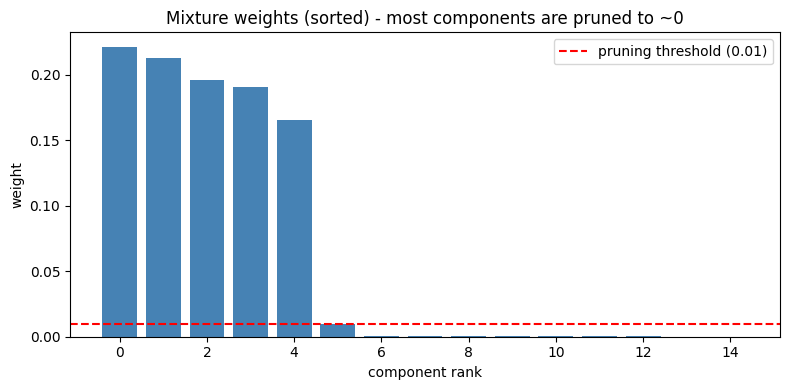

In [4]:
weights = result.weights
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(len(weights)), weights, color="steelblue")
ax.axhline(0.01, color="red", linestyle="--", label="pruning threshold (0.01)")
ax.set_title("Mixture weights (sorted) - most components are pruned to ~0")
ax.set_xlabel("component rank")
ax.set_ylabel("weight")
ax.legend()
plt.tight_layout()
plt.show()

## Baseline: choosing k by hand

The conventional approach is a silhouette sweep over candidate k. It works, but it is a manual search the practitioner must run and judge - whereas the Dirichlet-process model returned the count directly.

In [5]:
rows = []
for k in range(2, 11):
    labels = KMeans(n_clusters=k, n_init=10, random_state=0).fit_predict(x)
    rows.append({"k": k, "silhouette": silhouette_score(x, labels)})
sweep = pd.DataFrame(rows)
best_k = int(sweep.loc[sweep["silhouette"].idxmax(), "k"])
print(f"silhouette-optimal k (manual search): {best_k}")
print(f"Dirichlet-process effective components (automatic): {result.effective_components}")
sweep.round(3)

silhouette-optimal k (manual search): 5
Dirichlet-process effective components (automatic): 5


,k,silhouette
0,2,0.405
1,3,0.453
2,4,0.533
3,5,0.619
4,6,0.521
5,7,0.428
6,8,0.332
7,9,0.251
8,10,0.154


## Soft assignments and uncertainty

A mixture model assigns *probabilities*, not just hard labels. Points near a blob centre are assigned confidently (low entropy); points between blobs spread their responsibility (high entropy). This is information a hard KMeans label hides.

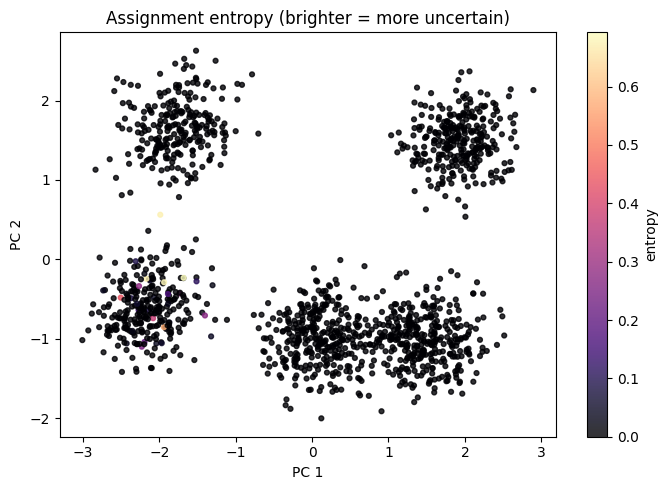

count    1500.000
mean        0.004
std         0.044
min         0.000
25%         0.000
50%         0.000
75%         0.000
max         0.693
Name: entropy, dtype: float64


In [6]:
uncertainty = assignment_uncertainty(result.model, x)
coords = PCA(n_components=2, random_state=42).fit_transform(x)

fig, ax = plt.subplots(figsize=(7, 5))
scatter = ax.scatter(
    coords[:, 0], coords[:, 1], c=uncertainty["entropy"], cmap="magma", s=12, alpha=0.8
)
ax.set_title("Assignment entropy (brighter = more uncertain)")
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")
fig.colorbar(scatter, label="entropy")
plt.tight_layout()
plt.show()
print(uncertainty["entropy"].describe().round(3))

## How much does the prior matter?

The concentration prior controls how strongly the model prefers fewer components. When clusters are well separated the inferred count is robust to it (a reassuring property). The prior bites only when structure is weak, as the overlapping example below shows.

In [7]:
import numpy as np

rng = np.random.default_rng(0)
overlapping = np.vstack(
    [rng.normal(loc=c, scale=1.6, size=(120, 2)) for c in ([0, 0], [3, 3], [0, 3], [3, 0])]
)

rows = []
for prior in (1e-3, 1.0, 1e3):
    for label, data in (("well-separated", x), ("overlapping", overlapping)):
        model = fit_dirichlet_process_mixture(
            data, max_components=15, weight_concentration_prior=prior,
            max_iter=500, random_state=0,
        )
        rows.append({"prior": prior, "data": label,
                     "effective": effective_components(model.weights_)})
pd.DataFrame(rows).pivot(index="prior", columns="data", values="effective")

data,overlapping,well-separated
prior,,
0.001,2,5
1.000,3,5
1000.000,4,5


## Interpretation and limitations

The Dirichlet-process mixture recovers the five latent segments from a generous upper bound of fifteen, without a manual k search, and adds calibrated soft assignments that flag boundary customers. On well-separated data the result is robust to the concentration prior.

**Limitations.**

- It assumes Gaussian components; genuinely non-elliptical clusters are modelled as several Gaussians, inflating the component count.
- 'Effective components' depends on a weight threshold; report it, do not hide it.
- Variational inference finds a local optimum and can fail to converge on weakly separated data (watch for convergence warnings).
- The upper bound and the prior are still modelling choices - fewer than before, but not zero.